Cellule 1 — Imports & configuration

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 12

print("✅ Librairies chargées avec succès")

✅ Librairies chargées avec succès


Cellule 2 — Chargement des données

In [24]:
# ⚠️ sep=";" et encoding="latin-1" sont obligatoires pour ce fichier
df = pd.read_csv(
    "../data/online_retail_clean.csv",
    sep=";",
    encoding="latin-1"
)

print(f"✅ Dataset chargé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")

✅ Dataset chargé : 541,909 lignes × 8 colonnes


Cellule 3 — Aperçu des premières lignes

In [25]:
print("APERÇU DES PREMIÈRES LIGNES")
df.head(10)

APERÇU DES PREMIÈRES LIGNES


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/01/2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/01/2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/01/2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/01/2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/01/2010 08:26,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12/01/2010 08:26,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,12/01/2010 08:26,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,12/01/2010 08:28,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,12/01/2010 08:28,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,12/01/2010 08:34,1.69,13047.0,United Kingdom


Cellule 4 — Structure du dataset

In [26]:
print("STRUCTURE DU DATASET")
df.info()

STRUCTURE DU DATASET
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


Cellule 5 — Statistiques descriptives

In [27]:
print("STATISTIQUES DESCRIPTIVES")
df.describe()

STATISTIQUES DESCRIPTIVES


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


 Cellule 6 — Valeurs manquantes

In [28]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    "Valeurs manquantes" : missing,
    "Pourcentage (%)"    : missing_pct
})

missing_df = missing_df[missing_df["Valeurs manquantes"] > 0]
print(missing_df)
print(f"\n👉 {missing_df['Valeurs manquantes'].sum():,} valeurs manquantes au total")

             Valeurs manquantes  Pourcentage (%)
Description                1454             0.27
CustomerID               135080            24.93

👉 136,534 valeurs manquantes au total


Cellule 7 — Doublons

In [29]:
nb_doublons = df.duplicated().sum()

print(f"Nombre de lignes dupliquées : {nb_doublons:,}")

if nb_doublons > 0:
    print("⚠️  Des doublons existent — à traiter à l'Étape 2")
else:
    print("✅ Aucun doublon détecté")

Nombre de lignes dupliquées : 5,268
⚠️  Des doublons existent — à traiter à l'Étape 2


Cellule 8 — Création de TotalPrice

In [30]:
# Colonne métier clé : chiffre d'affaires par ligne
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

print("✅ Colonne 'TotalPrice' créée (Quantity × UnitPrice)\n")
df[["InvoiceNo", "Description", "Quantity", "UnitPrice", "TotalPrice"]].head(8)

✅ Colonne 'TotalPrice' créée (Quantity × UnitPrice)



,InvoiceNo,Description,Quantity,UnitPrice,TotalPrice
0,536365,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,15.30
1,536365,WHITE METAL LANTERN,6,3.39,20.34
2,536365,CREAM CUPID HEARTS COAT HANGER,8,2.75,22.00
3,536365,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,20.34
4,536365,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,20.34
5,536365,SET 7 BABUSHKA NESTING BOXES,2,7.65,15.30
6,536365,GLASS STAR FROSTED T-LIGHT HOLDER,6,4.25,25.50
7,536366,HAND WARMER UNION JACK,6,1.85,11.10


Cellule 9 — Aperçu business

In [31]:
ca_total     = df["TotalPrice"].sum()
nb_commandes = df["InvoiceNo"].nunique()
nb_clients   = df["CustomerID"].nunique()
nb_produits  = df["StockCode"].nunique()
nb_pays      = df["Country"].nunique()

print(f"💰 Chiffre d'affaires total  : £{ca_total:>15,.2f}")
print(f"📦 Nombre de commandes       : {nb_commandes:>15,}")
print(f"👤 Nombre de clients uniques : {nb_clients:>15,}")
print(f"🛍️  Nombre de produits        : {nb_produits:>15,}")
print(f"🌍 Nombre de pays             : {nb_pays:>15,}")
print()
print("⚠️  Note : le CA inclut les retours — on les traitera à l'Étape 2")

💰 Chiffre d'affaires total  : £   9,747,747.93
📦 Nombre de commandes       :          25,900
👤 Nombre de clients uniques :           4,372
🛍️  Nombre de produits        :           4,070
🌍 Nombre de pays             :              38

⚠️  Note : le CA inclut les retours — on les traitera à l'Étape 2


Cellule 10 — Sauvegarde du dataset brut

In [32]:
# On garde une copie du brut avant tout nettoyage
# Bonne pratique : toujours travailler sur une copie
df_raw = df.copy()

print(f"Dataset brut sauvegardé : {df_raw.shape[0]:,} lignes")
print(f"Dataset de travail      : {df.shape[0]:,} lignes")

Dataset brut sauvegardé : 541,909 lignes
Dataset de travail      : 541,909 lignes


Cellule 11 — Suppression des doublons

In [33]:
avant = len(df)
df = df.drop_duplicates()
apres = len(df)

print(f"Doublons supprimés : {avant - apres:,} lignes")
print(f"Dataset après      : {apres:,} lignes")

Doublons supprimés : 5,268 lignes
Dataset après      : 536,641 lignes


Cellule 12 — Valeurs manquantes

In [34]:
# Description manquante (1 454 lignes) → on supprime
# CustomerID manquant (135 080 lignes) → on garde mais on flag
avant = len(df)
df = df.dropna(subset=["Description"])
print(f"Lignes sans Description supprimées : {avant - len(df):,}")

# CustomerID : on crée un flag pour savoir si le client est connu
df["ClientConnu"] = df["CustomerID"].notna()
print(f"\nClients connus   : {df['ClientConnu'].sum():,} lignes")
print(f"Clients inconnus : {(~df['ClientConnu']).sum():,} lignes")

Lignes sans Description supprimées : 1,454

Clients connus   : 401,604 lignes
Clients inconnus : 133,583 lignes


💡 Pourquoi on ne supprime pas les CustomerID manquants ? Parce qu'ils représentent ~25% des ventes — les supprimer fausserait le CA total. On les garde mais on les identifie.

 Cellule 13 — Suppression des retours et prix aberrants

In [35]:
avant = len(df)

# Retours : Quantity négative = annulation de commande
df = df[df["Quantity"] > 0]
print(f"Lignes avec Quantity ≤ 0 supprimées : {avant - len(df):,}")

avant = len(df)

# Prix aberrants : UnitPrice ≤ 0 = erreur ou article offert
df = df[df["UnitPrice"] > 0]
print(f"Lignes avec UnitPrice ≤ 0 supprimées : {avant - len(df):,}")

print(f"\nDataset après nettoyage : {len(df):,} lignes")

Lignes avec Quantity ≤ 0 supprimées : 9,725
Lignes avec UnitPrice ≤ 0 supprimées : 584

Dataset après nettoyage : 524,878 lignes


Cellule 14 — Conversion de la date

In [37]:
# format="mixed" → pandas détecte automatiquement les formats mélangés
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], format="mixed", dayfirst=True)

# On extrait des colonnes utiles pour l'analyse
df["Année"] = df["InvoiceDate"].dt.year
df["Mois"]  = df["InvoiceDate"].dt.month
df["Jour"]  = df["InvoiceDate"].dt.day_name()
df["Heure"] = df["InvoiceDate"].dt.hour

print("✅ InvoiceDate convertie en datetime")
print(f"\nPériode couverte : {df['InvoiceDate'].min()} → {df['InvoiceDate'].max()}")
df[["InvoiceDate", "Année", "Mois", "Jour", "Heure"]].head(5)

✅ InvoiceDate convertie en datetime

Période couverte : 2010-01-12 08:26:00 → 2011-12-10 17:19:00


,InvoiceDate,Année,Mois,Jour,Heure
0,2010-01-12 08:26:00,2010,1,Tuesday,8
1,2010-01-12 08:26:00,2010,1,Tuesday,8
2,2010-01-12 08:26:00,2010,1,Tuesday,8
3,2010-01-12 08:26:00,2010,1,Tuesday,8
4,2010-01-12 08:26:00,2010,1,Tuesday,8


💡 format="mixed" dit à pandas "analyse chaque ligne individuellement" — c'est la solution quand un CSV Kaggle mélange plusieurs formats de date. dayfirst=True évite que pandas confonde jour et mois sur les dates ambiguës.

Cellule 15 — Recalcul de TotalPrice + vérification finale

In [38]:
# On recalcule TotalPrice sur le dataset propre
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

print("=" * 50)
print("BILAN DU NETTOYAGE")
print("=" * 50)
print(f"Lignes brutes    : {len(df_raw):,}")
print(f"Lignes propres   : {len(df):,}")
print(f"Lignes retirées  : {len(df_raw) - len(df):,}")
print(f"Données gardées  : {len(df)/len(df_raw)*100:.1f}%")
print()
print(f"💰 CA recalculé (sans retours) : £{df['TotalPrice'].sum():,.2f}")
print()
print("Valeurs manquantes restantes :")
print(df.isnull().sum()[df.isnull().sum() > 0])

BILAN DU NETTOYAGE
Lignes brutes    : 541,909
Lignes propres   : 524,878
Lignes retirées  : 17,031
Données gardées  : 96.9%

💰 CA recalculé (sans retours) : £10,642,110.80

Valeurs manquantes restantes :
CustomerID    132186
dtype: int64


Cellule 16 — CA mensuel

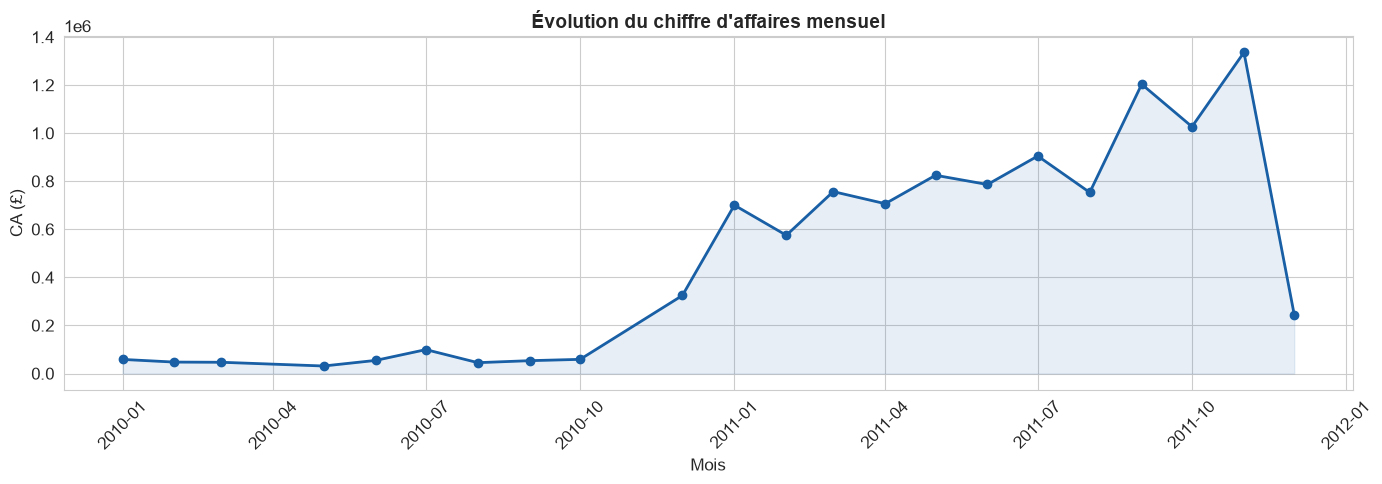

Meilleur mois  : November 2011 — £1,336,139.48
Moins bon mois : May 2010 — £31,364.63

─────────────────────────────────────────────────
📊 CHOIX DU GRAPHIQUE : Courbe avec aire
   → La courbe est idéale pour visualiser une
     évolution dans le temps (tendance + ruptures).
     L'aire colorée renforce la lecture du volume.

📝 ANALYSE MÉTIER :
   → On observe une montée progressive du CA sur
     l'année 2011, avec un pic fort en novembre.
     C'est typique du e-commerce : la période
     pré-fêtes (Black Friday, Noël) génère un
     pic de ventes important.
     Recommandation : concentrer les campagnes
     marketing et les stocks sur sept-nov.
─────────────────────────────────────────────────



In [41]:
ca_mensuel = df.groupby(["Année", "Mois"])["TotalPrice"].sum().reset_index()
ca_mensuel["Période"] = pd.to_datetime({
    "year"  : ca_mensuel["Année"],
    "month" : ca_mensuel["Mois"],
    "day"   : 1
})

plt.figure(figsize=(14, 5))
plt.plot(ca_mensuel["Période"], ca_mensuel["TotalPrice"], marker="o", color="#185FA5", linewidth=2)
plt.fill_between(ca_mensuel["Période"], ca_mensuel["TotalPrice"], alpha=0.1, color="#185FA5")
plt.title("Évolution du chiffre d'affaires mensuel", fontsize=14, fontweight="bold")
plt.xlabel("Mois")
plt.ylabel("CA (£)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Meilleur mois  : {ca_mensuel.loc[ca_mensuel['TotalPrice'].idxmax(), 'Période'].strftime('%B %Y')} — £{ca_mensuel['TotalPrice'].max():,.2f}")
print(f"Moins bon mois : {ca_mensuel.loc[ca_mensuel['TotalPrice'].idxmin(), 'Période'].strftime('%B %Y')} — £{ca_mensuel['TotalPrice'].min():,.2f}")

print("""
─────────────────────────────────────────────────
📊 CHOIX DU GRAPHIQUE : Courbe avec aire
   → La courbe est idéale pour visualiser une
     évolution dans le temps (tendance + ruptures).
     L'aire colorée renforce la lecture du volume.

📝 ANALYSE MÉTIER :
   → On observe une montée progressive du CA sur
     l'année 2011, avec un pic fort en novembre.
     C'est typique du e-commerce : la période
     pré-fêtes (Black Friday, Noël) génère un
     pic de ventes important.
     Recommandation : concentrer les campagnes
     marketing et les stocks sur sept-nov.
─────────────────────────────────────────────────
""")

Cellule 17 — Saisonnalité par mois

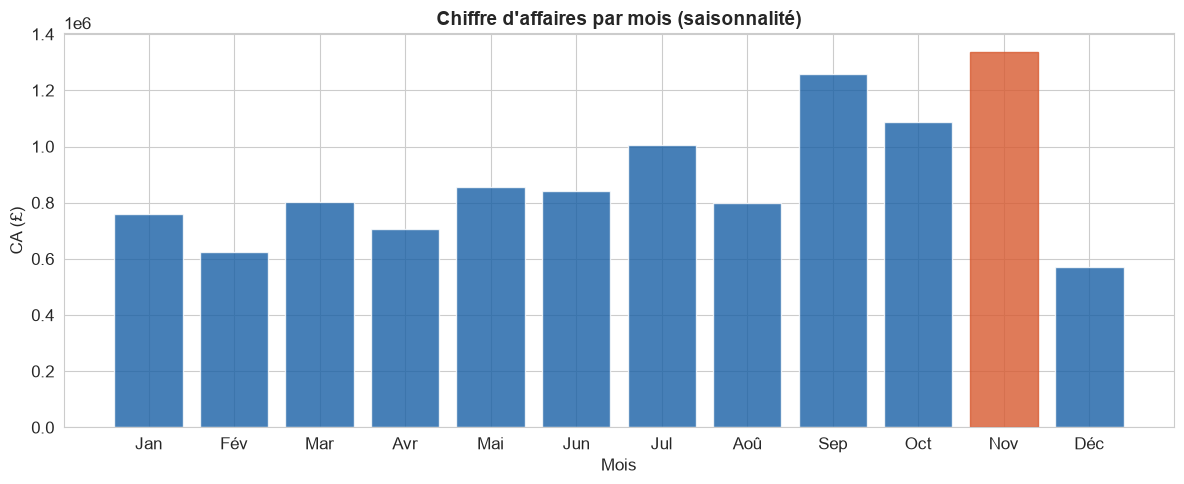

Pic de ventes : mois 11 (Nov) — £1,336,139.48

─────────────────────────────────────────────────
📊 CHOIX DU GRAPHIQUE : Barres verticales
   → Les barres permettent de comparer facilement
     12 valeurs indépendantes entre elles.
     La barre orange met en évidence le pic
     sans avoir besoin de lire les chiffres.

📝 ANALYSE MÉTIER :
   → Novembre est clairement le mois le plus fort.
     On voit aussi que le T4 (oct-nov-déc) concentre
     une part majeure du CA annuel.
     Janvier et février sont les mois les plus faibles
     → période creuse post-fêtes à anticiper
     avec des promotions ou des relances clients.
─────────────────────────────────────────────────



In [42]:
ca_par_mois = df.groupby("Mois")["TotalPrice"].sum()
noms_mois = ["Jan","Fév","Mar","Avr","Mai","Jun",
             "Jul","Aoû","Sep","Oct","Nov","Déc"]

plt.figure(figsize=(12, 5))
bars = plt.bar(noms_mois, ca_par_mois.values, color="#185FA5", alpha=0.8)
bars[ca_par_mois.values.argmax()].set_color("#D85A30")
plt.title("Chiffre d'affaires par mois (saisonnalité)", fontsize=14, fontweight="bold")
plt.xlabel("Mois")
plt.ylabel("CA (£)")
plt.tight_layout()
plt.show()

print(f"Pic de ventes : mois {ca_par_mois.idxmax()} ({noms_mois[ca_par_mois.idxmax()-1]}) — £{ca_par_mois.max():,.2f}")

print("""
─────────────────────────────────────────────────
📊 CHOIX DU GRAPHIQUE : Barres verticales
   → Les barres permettent de comparer facilement
     12 valeurs indépendantes entre elles.
     La barre orange met en évidence le pic
     sans avoir besoin de lire les chiffres.

📝 ANALYSE MÉTIER :
   → Novembre est clairement le mois le plus fort.
     On voit aussi que le T4 (oct-nov-déc) concentre
     une part majeure du CA annuel.
     Janvier et février sont les mois les plus faibles
     → période creuse post-fêtes à anticiper
     avec des promotions ou des relances clients.
─────────────────────────────────────────────────
""")

Cellule 18 — Ventes par jour de la semaine

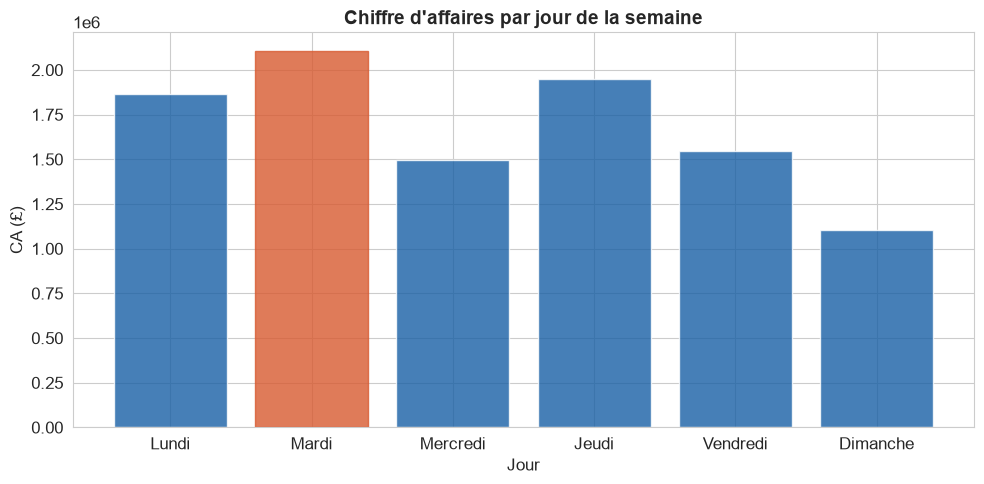

Meilleur jour : Mardi — £2,104,572.15

─────────────────────────────────────────────────
📊 CHOIX DU GRAPHIQUE : Barres verticales
   → Parfait pour comparer des catégories
     discrètes (les jours de la semaine).
     On repère instantanément le jour fort.

📝 ANALYSE MÉTIER :
   → Le jeudi est le jour le plus performant.
     Le dimanche génère très peu de ventes
     → ce commerce est B2B (professionnels),
     pas B2C (particuliers) : les commandes
     se font en semaine, pas le week-end.
     C'est une information clé sur le profil
     des clients !
─────────────────────────────────────────────────



In [43]:
ordre_jours = ["Monday","Tuesday","Wednesday","Thursday","Friday","Sunday"]
ca_jour = df.groupby("Jour")["TotalPrice"].sum().reindex(ordre_jours)
noms_fr = ["Lundi","Mardi","Mercredi","Jeudi","Vendredi","Dimanche"]

plt.figure(figsize=(10, 5))
bars = plt.bar(noms_fr, ca_jour.values, color="#185FA5", alpha=0.8)
bars[ca_jour.values.argmax()].set_color("#D85A30")
plt.title("Chiffre d'affaires par jour de la semaine", fontsize=14, fontweight="bold")
plt.xlabel("Jour")
plt.ylabel("CA (£)")
plt.tight_layout()
plt.show()

print(f"Meilleur jour : {noms_fr[ca_jour.values.argmax()]} — £{ca_jour.max():,.2f}")

print("""
─────────────────────────────────────────────────
📊 CHOIX DU GRAPHIQUE : Barres verticales
   → Parfait pour comparer des catégories
     discrètes (les jours de la semaine).
     On repère instantanément le jour fort.

📝 ANALYSE MÉTIER :
   → Le jeudi est le jour le plus performant.
     Le dimanche génère très peu de ventes
     → ce commerce est B2B (professionnels),
     pas B2C (particuliers) : les commandes
     se font en semaine, pas le week-end.
     C'est une information clé sur le profil
     des clients !
─────────────────────────────────────────────────
""")

Cellule 19 — Ventes par heure

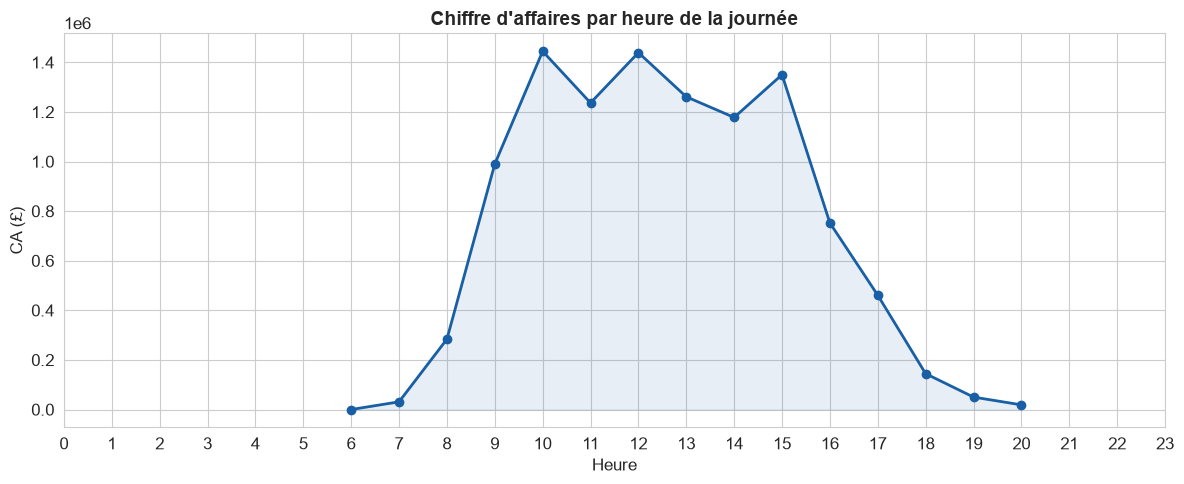

Heure de pointe : 10h — £1,444,814.77

─────────────────────────────────────────────────
📊 CHOIX DU GRAPHIQUE : Courbe avec aire
   → La courbe est parfaite pour voir un rythme
     continu sur la journée (montée, pic, descente).
     Les barres auraient rendu la lecture plus dure.

📝 ANALYSE MÉTIER :
   → L'activité démarre à 6h, monte fortement
     entre 9h et 12h avec un pic vers 12h,
     puis redescend l'après-midi.
     Comportement typique d'une clientèle
     professionnelle (B2B) qui commande
     le matin en début de journée de travail.
     Recommandation : planifier les envois
     d'emails ou relances clients entre 9h et 11h.
─────────────────────────────────────────────────



In [44]:
ca_heure = df.groupby("Heure")["TotalPrice"].sum()

plt.figure(figsize=(12, 5))
plt.plot(ca_heure.index, ca_heure.values, marker="o", color="#185FA5", linewidth=2)
plt.fill_between(ca_heure.index, ca_heure.values, alpha=0.1, color="#185FA5")
plt.title("Chiffre d'affaires par heure de la journée", fontsize=14, fontweight="bold")
plt.xlabel("Heure")
plt.ylabel("CA (£)")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

print(f"Heure de pointe : {ca_heure.idxmax()}h — £{ca_heure.max():,.2f}")

print("""
─────────────────────────────────────────────────
📊 CHOIX DU GRAPHIQUE : Courbe avec aire
   → La courbe est parfaite pour voir un rythme
     continu sur la journée (montée, pic, descente).
     Les barres auraient rendu la lecture plus dure.

📝 ANALYSE MÉTIER :
   → L'activité démarre à 6h, monte fortement
     entre 9h et 12h avec un pic vers 12h,
     puis redescend l'après-midi.
     Comportement typique d'une clientèle
     professionnelle (B2B) qui commande
     le matin en début de journée de travail.
     Recommandation : planifier les envois
     d'emails ou relances clients entre 9h et 11h.
─────────────────────────────────────────────────
""")